In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("DataInsightAgent") \
    .getOrCreate()

df1 = spark.createDataFrame(df)

df1.show(5)

+----------+----+------+------+---+------+----+
|total_bill| tip|   sex|smoker|day|  time|size|
+----------+----+------+------+---+------+----+
|     16.99|1.01|Female|    No|Sun|Dinner|   2|
|     10.34|1.66|  Male|    No|Sun|Dinner|   3|
|     21.01| 3.5|  Male|    No|Sun|Dinner|   3|
|     23.68|3.31|  Male|    No|Sun|Dinner|   2|
|     24.59|3.61|Female|    No|Sun|Dinner|   4|
+----------+----+------+------+---+------+----+
only showing top 5 rows


In [ ]:
df1.printSchema()

root
 |-- total_bill: double (nullable = true)
 |-- tip: double (nullable = true)
 |-- sex: string (nullable = true)
 |-- smoker: string (nullable = true)
 |-- day: string (nullable = true)
 |-- time: string (nullable = true)
 |-- size: long (nullable = true)



In [ ]:
from pyspark.sql.functions import sum, avg, desc

def analyze_data(question):

    q = question.lower()

    if "total tips" in q:

        result = (
            df1.groupBy("day")
            .agg(sum("tip").alias("total_tip"))
            .orderBy(desc("total_tip"))
        )

        return result

    elif "average bill" in q:

        result = (
            df1.groupBy("day")
            .agg(avg("total_bill").alias("avg_bill"))
            .orderBy(desc("avg_bill"))
        )

        return result

    elif "smoker" in q:

        result = (
            df1.groupBy("smoker")
            .agg(avg("tip").alias("avg_tip"))
        )

        return result

    else:

        return None

In [ ]:
result = analyze_data(
    "what is total tips?"
)

result.show()

+----+------------------+
| day|         total_tip|
+----+------------------+
| Sat|260.40000000000003|
| Sun|247.39000000000001|
|Thur|            171.83|
| Fri|             51.96|
+----+------------------+



In [ ]:
result_pd = result.toPandas()

result_pd

,day,total_tip
0,Sat,260.40
1,Sun,247.39
2,Thur,171.83
3,Fri,51.96


In [ ]:
from google.colab import userdata
from google import genai

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)
def generate_summary(question, result_pd):

    prompt = f"""
    User Question:
    {question}

    Analysis Result:
    {result_pd.to_string()}

    Write 3-4 business insights.
    """

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=prompt
    )

    return response.text

In [ ]:
import matplotlib.pyplot as plt

def generate_chart(question, result_pd):

    columns = result_pd.columns

    x_col = columns[0]
    y_col = columns[1]

    plt.figure(figsize=(8,5))

    plt.bar(
        result_pd[x_col],
        result_pd[y_col]
    )

    plt.title(question)

    plt.xlabel(x_col)

    plt.ylabel(y_col)

    plt.show()

In [ ]:
memory = {}

In [ ]:
def save_question(question):
    memory["last_question"] = question

In [ ]:
def get_last_question():
    return memory.get(
        "last_question",
        "No previous question found"
    )

In [ ]:
save_question(
    "Which day has highest total tips?"
)

print(get_last_question())

Which day has highest total tips?


In [ ]:
def insight_tool(question):

    save_question(question)

    result = analyze_data(question)

    if result is None:
        return "Question not supported."

    result_pd = result.toPandas()

    # Display graph
    generate_chart(
        question,
        result_pd
    )

    # Generate summary
    summary = generate_summary(
        question,
        result_pd
    )

    return summary

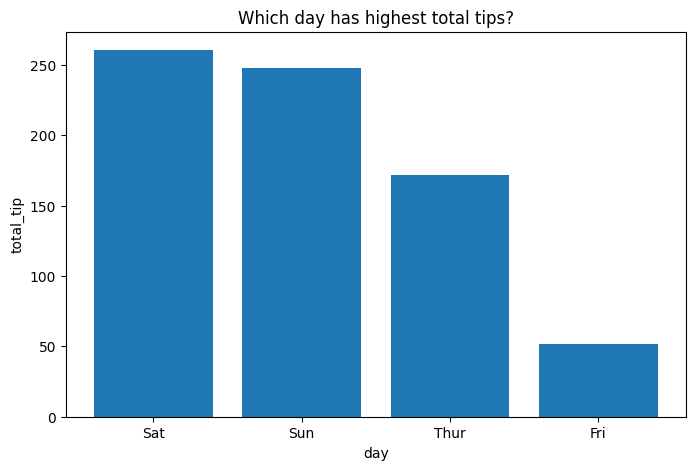

Based on the data provided, **Saturday** has the highest total tips at **$260.40**. 

Here are **4 key business insights** derived from the analysis:

1. **Weekend Dominance Drives Revenue:** 
   Saturday ($260.40) and Sunday ($247.39) combined generate **$507.79**, representing over **69% of total tips**. This indicates that weekend dining is the primary driver of customer volume and higher spending.

2. **Optimize Peak-Hour Staffing Strategy:** 
   Because tip totals are highest on Saturday and Sunday, management should schedule senior and highly efficient front-of-house staff on these days to ensure quick table turnover and high customer satisfaction during peak demand.

3. **Underperformance Opportunity on Fridays:** 
   Friday generated the lowest total tips at just **$51.96**—underperforming even Thursday ($171.83). This signals a clear growth opportunity; launching targeted marketing campaigns (e.g., Friday Happy Hours, dinner specials, or live music) could help boost foot traff

In [ ]:
question = "Which day has highest total tips?"

output = insight_tool(question)

print(output)

In [ ]:
root_agent = Agent(
    name="data_insight_agent",

    model="gemini-3.5-flash",

    description="Tips analytics agent",

    instruction="""
    Use insight_tool for all analytical
    questions regarding tips dataset.
    """,

    tools=[insight_tool]
)